# Robot Workspace Analysis – Robotics Toolbox 
**Goal:** Visualize and **verify** robot’s **3D workspace** and singularity analysis

In [1]:
import numpy as np
import roboticstoolbox as rtb
from spatialmath import SE3
import matplotlib.pyplot as plt

#### **Step 1: Create Robot Model**

In [2]:
L1 = rtb.RevoluteMDH(alpha=0,       a=0,      d=0.2,  offset=0, qlim=[-np.pi/2, np.pi/2])
L2 = rtb.RevoluteMDH(alpha=np.pi/2, a=0,      d=0.12,    offset=0, qlim=[-np.pi/2, np.pi/2])
L3 = rtb.RevoluteMDH(alpha=0,       a=0.25,   d=-0.1, offset=0, qlim=[-np.pi/2, np.pi/2])

tool = SE3(0.28, 0, 0)
robot = rtb.DHRobot([L1, L2, L3], name='RRR_robot', tool=tool)

print(robot)

DHRobot: RRR_robot, 3 joints (RRR), dynamics, modified DH parameters
┌──────┬───────┬─────┬──────┬────────┬───────┐
│ aⱼ₋₁ │ ⍺ⱼ₋₁  │ θⱼ  │  dⱼ  │   q⁻   │  q⁺   │
├──────┼───────┼─────┼──────┼────────┼───────┤
│    0 │  0.0° │  q1 │  0.2 │ -90.0° │ 90.0° │
│    0 │ 90.0° │  q2 │ 0.12 │ -90.0° │ 90.0° │
│ 0.25 │  0.0° │  q3 │ -0.1 │ -90.0° │ 90.0° │
└──────┴───────┴─────┴──────┴────────┴───────┘

┌──────┬──────────────────────────────────────┐
│ tool │ t = 0.28, 0, 0; rpy/xyz = 0°, 0°, 0° │
└──────┴──────────────────────────────────────┘



#### **Step 2: Computes forward kinematics at home configuration**

In [3]:
q = [0, 0, 0]
T = robot.fkine(q)
print(T)

   1         0         0         0.53      
   0         0        -1        -0.02      
   0         1         0         0.2       
   0         0         0         1         



#### **Step 3: Generate & Plot 3D Workspace**
Ignore Ground Collision

/tmp/ipykernel_188756/1401401214.py:35: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(p, ax=ax, label='Z (m)')


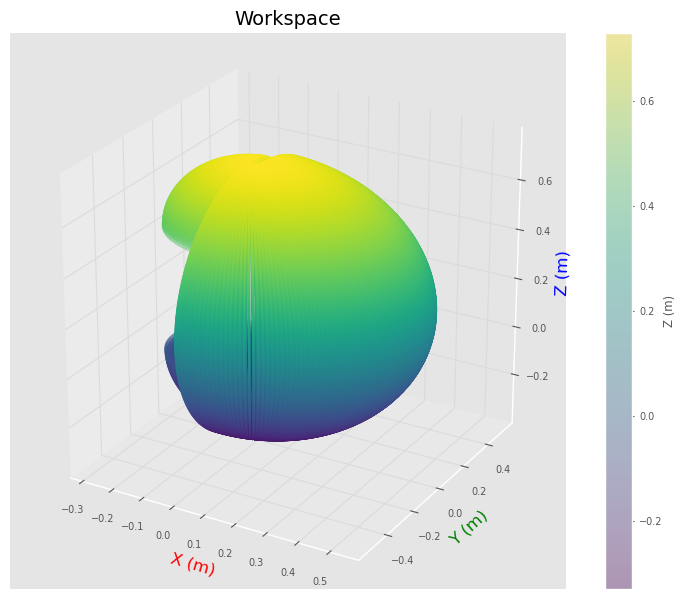

Bounds [min, max] (m):
X: -0.281 → 0.530
Y: -0.530 → 0.530
Z: -0.330 → 0.730

Horizontal reach ρ: 0.020 → 0.530 m


In [4]:
n2, n3 = 121, 121
q2_vals = np.linspace(L2.qlim[0], L2.qlim[1], n2)
q3_vals = np.linspace(L3.qlim[0], L3.qlim[1], n3)

Q2, Q3 = np.meshgrid(q2_vals, q3_vals, indexing='ij')
Qs23 = np.column_stack([np.zeros(Q2.size), Q2.ravel(), Q3.ravel()])

pos = np.array([robot.fkine(qi).t for qi in Qs23])
x0, y0, z0 = pos[:, 0], pos[:, 1], pos[:, 2]

n1 = 121
q1_vals = np.linspace(L1.qlim[0], L1.qlim[1], n1)
c, s = np.cos(q1_vals), np.sin(q1_vals)

Xf, Yf, Zf = [], [], []

for ci, si in zip(c, s):
    Xf.append(ci * x0 - si * y0)
    Yf.append(si * x0 + ci * y0)
    Zf.append(z0)

Xf, Yf, Zf = np.concatenate(Xf), np.concatenate(Yf), np.concatenate(Zf)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(Xf, Yf, Zf, c=Zf, s=1, alpha=0.35)

ax.set_xlabel('X (m)', color='r', fontsize=12)
ax.set_ylabel('Y (m)', color='g', fontsize=12)
ax.set_zlabel('Z (m)', color='b', fontsize=12)
ax.set_box_aspect([1,1,1])
ax.grid(True, alpha=0.3)
ax.view_init(elev=25, azim=-60)
plt.title('Workspace', fontsize=14)
plt.colorbar(p, ax=ax, label='Z (m)')
plt.tight_layout()
plt.show()

r = np.sqrt(Xf**2 + Yf**2)
print(f"Bounds [min, max] (m):")
print(f"X: {Xf.min():.3f} → {Xf.max():.3f}")
print(f"Y: {Yf.min():.3f} → {Yf.max():.3f}")
print(f"Z: {Zf.min():.3f} → {Zf.max():.3f}")
print(f"\nHorizontal reach ρ: {r.min():.3f} → {r.max():.3f} m")

rho_ignore_ground = r
z_ignore_ground = Zf

Include Ground Collision

In [ ]:
n2, n3 = 121, 121
q2_vals = np.linspace(L2.qlim[0], L2.qlim[1], n2)
q3_vals = np.linspace(L3.qlim[0], L3.qlim[1], n3)

Q2, Q3 = np.meshgrid(q2_vals, q3_vals, indexing='ij')
Qs23 = np.column_stack([np.zeros(Q2.size), Q2.ravel(), Q3.ravel()])

pos = []
for qi in Qs23:
    Ts = robot.fkine_all(qi)
    z_links = [T.t[2] for T in Ts]
    z_pairs = list(zip(z_links[:-1], z_links[1:]))
    if all((z1 >= 0 and z2 >= 0 and z1 * z2 >= 0) for z1, z2 in z_pairs):
        pos.append(Ts[-1].t)

pos = np.array(pos)
x0, y0, z0 = pos[:, 0], pos[:, 1], pos[:, 2]

n1 = 121
q1_vals = np.linspace(L1.qlim[0], L1.qlim[1], n1)
c, s = np.cos(q1_vals), np.sin(q1_vals)

Xf, Yf, Zf = [], [], []
for ci, si in zip(c, s):
    Xf.append(ci * x0 - si * y0)
    Yf.append(si * x0 + ci * y0)
    Zf.append(z0)

Xf, Yf, Zf = np.concatenate(Xf), np.concatenate(Yf), np.concatenate(Zf)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(Xf, Yf, Zf, c=Zf, s=1, alpha=0.35)
ax.set_xlabel('X (m)', color='r', fontsize=12)
ax.set_ylabel('Y (m)', color='g', fontsize=12)
ax.set_zlabel('Z (m)', color='b', fontsize=12)
ax.set_box_aspect([1,1,1])
ax.grid(True, alpha=0.3)
ax.view_init(elev=25, azim=-60)
plt.title('Workspace (Ground Collision)', fontsize=14)
plt.colorbar(p, ax=ax, label='Z (m)')
plt.tight_layout()
plt.show()

r = np.sqrt(Xf**2 + Yf**2)
print(f"Bounds [min, max] (m):")
print(f"X: {Xf.min():.3f} → {Xf.max():.3f}")
print(f"Y: {Yf.min():.3f} → {Yf.max():.3f}")
print(f"Z: {Zf.min():.3f} → {Zf.max():.3f}")
print(f"\nHorizontal reach ρ: {r.min():.3f} → {r.max():.3f} m")

rho_with_ground = r
z_with_ground = Zf


/tmp/ipykernel_188756/1240538905.py:41: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(p, ax=ax, label='Z (m)')


#### **Step 4: Create Inequality Equations of Workspace**

In [ ]:
def in_workspace(x, y, z):
    rho2 = x**2 + y**2
    return (r.min()**2 <= rho2 <= r.max()**2) and (Zf.min() <= z <= Zf.max())

def workspace_function(x, y, z):
    f1 = r.min()**2 - (x**2 + y**2)
    f2 = (x**2 + y**2) - r.max()**2
    f3 = Zf.min() - z
    f4 = z - Zf.max()
    return max(f1, f2, f3, f4)

points = [
    (0.1, 0.0, 0.2),
    (0.6, 0.0, 0.2),
    (0.1, 0.1, -0.5)
]

for p in points:
    print(f"Point {p}: inside workspace? {in_workspace(*p)}")

#### **Step 5: Test Inverse Kinematic**

In [ ]:
def random_reachable_point():
    while True:
        x = np.random.uniform(Xf.min(), Xf.max())
        y = np.random.uniform(Yf.min(), Yf.max())
        z = np.random.uniform(Zf.min(), Zf.max())
        if in_workspace(x, y, z):
            return np.array([x, y, z])


def check_ground_collision(q):
    """Return True if any link dips below z=0."""
    Ts = robot.fkine_all(q)
    z_links = [T.t[2] for T in Ts]
    for z1, z2 in zip(z_links[:-1], z_links[1:]):
        if z1 < 0 or z2 < 0 or z1 * z2 < 0:
            return True
    return False


num_points = 25
success_count = 0
fail_count = 0
collision_count = 0
results = []

for i in range(num_points):
    p = random_reachable_point()
    T = SE3(p[0], p[1], p[2])

    sol = robot.ikine_LM(T, mask=[1,1,1,0,0,0], tol=1e-5, ilimit=2000)

    print(f"\nPoint {i+1:02d}: x={p[0]:.3f}, y={p[1]:.3f}, z={p[2]:.3f}")

    if sol.success:
        q = sol.q
        if check_ground_collision(q):
            collision_count += 1
            print("→ IK found solution but robot collides with ground ❌")
            results.append((p, q, None, False))
        else:
            success_count += 1
            q = np.round(q, 3)
            T_check = robot.fkine(sol.q)
            pos_err = np.linalg.norm(T_check.t - p)
            results.append((p, q, pos_err, True))

            print("→ IK success (no ground collision)")
            print(f"  q = {q}")
            print(f"  Position error: {pos_err:.6f} m")
    else:
        fail_count += 1
        print("→ IK failed")

print("\n==================== Summary ====================")
print(f"Total tested points : {num_points}")
print(f"Successful solutions: {success_count}")
print(f"Ground collisions   : {collision_count}")
print(f"Failed solutions    : {fail_count}")
print(f"True success rate   : {100 * success_count / num_points:.1f}%")
print("=================================================")



Point 01: x=-0.008, y=0.221, z=0.090
→ IK success (no ground collision)
  q = [ 1.698  0.737 -2.182]
  Position error: 0.000041 m

Point 02: x=0.124, y=-0.023, z=0.440
→ IK success (no ground collision)
  q = [-0.026 -0.044  2.077]
  Position error: 0.000010 m

Point 03: x=0.228, y=0.092, z=0.002
→ IK success (no ground collision)
  q = [ 0.463  0.335 -1.875]
  Position error: 0.000001 m

Point 04: x=0.152, y=-0.135, z=0.301
→ IK success (no ground collision)
  q = [-0.628 -0.793  2.267]
  Position error: 0.000022 m

Point 05: x=0.156, y=-0.170, z=0.287
→ IK success (no ground collision)
  q = [-0.741  1.561 -2.184]
  Position error: 0.000011 m

Point 06: x=0.062, y=-0.048, z=0.414
→ IK success (no ground collision)
  q = [-0.406 -0.02   2.261]
  Position error: 0.000002 m

Point 07: x=0.049, y=0.204, z=0.022
→ IK found solution but robot collides with ground ❌

Point 08: x=0.100, y=-0.064, z=0.063
→ IK success (no ground collision)
  q = [-0.401  0.521 -2.456]
  Position error: 0.000